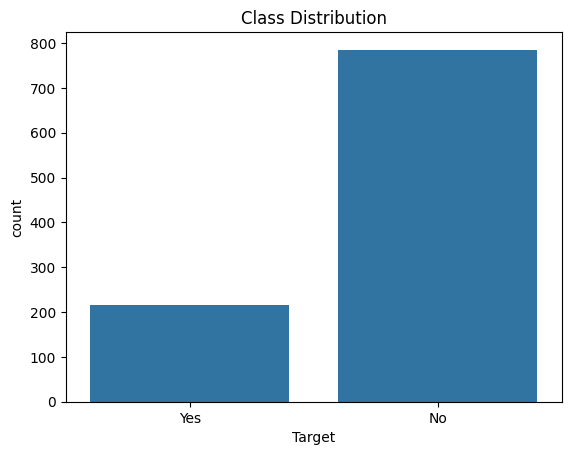

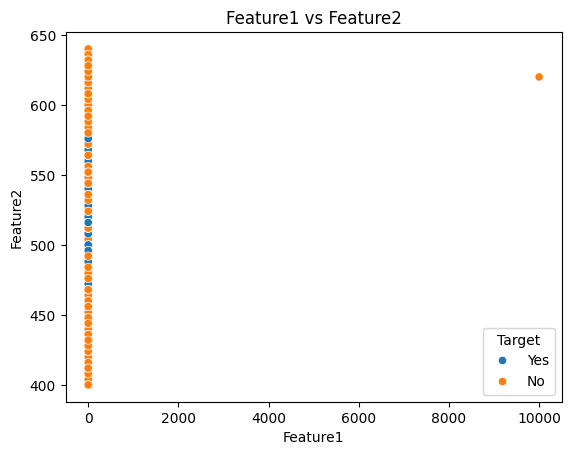

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/Lab_Exam_binary_classification_dataset.csv")

df.head()
df.isnull().sum()
sns.countplot(x="Target", data=df)
plt.title("Class Distribution")
plt.show()
sns.scatterplot(x="Feature1", y="Feature2", hue="Target", data=df)

plt.title("Feature1 vs Feature2")
plt.show()



In [41]:
df = df[df["Feature1"] < 1000]
# Drop rows with NaN values in the target column and update df
df = df.dropna(subset=[df.columns[-1]])
df["Target"].value_counts()

,count
Target,
0.0,784
1.0,215


In [46]:
from sklearn.utils import resample

# Separate classes using numerical labels
df_majority = df[df.Target == 0.0]
df_minority = df[df.Target == 1.0]

# Oversample minority class
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority), # Use the actual size of the majority class
    random_state=42
)

# Combine datasets
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Check new distribution
df_balanced["Target"].value_counts()

,count
Target,
0.0,784
1.0,784


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression
import numpy as np

model = LogisticRegression(class_weight='balanced')

# Check if y_train contains NaN values and clean if necessary
if y_train.isnull().any():
    print("Warning: y_train contains NaN values. Removing them and corresponding X_train rows.")
    # Get boolean mask for non-null values in y_train
    valid_indices = ~y_train.isnull()

    # Filter X_train (numpy array) using the boolean mask
    X_train_clean = X_train[valid_indices.values]
    # Filter y_train (pandas Series) by dropping NaNs
    y_train_clean = y_train.dropna()
else:
    # If no NaNs, use the original X_train and y_train
    X_train_clean = X_train
    y_train_clean = y_train

model.fit(X_train_clean, y_train_clean)

LogisticRegression(class_weight='balanced')

In [51]:
df["Target"] = df["Target"].map({"No":0, "Yes":1})

In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Check if y_test contains NaN values and clean if necessary
if y_test.isnull().any():
    print("Warning: y_test contains NaN values. Removing them and corresponding X_test rows.")
    # Get boolean mask for non-null values in y_test
    valid_indices_test = ~y_test.isnull()

    # Filter X_test (numpy array) using the boolean mask
    X_test_clean = X_test[valid_indices_test.values]
    # Filter y_test (pandas Series) by dropping NaNs
    y_test_clean = y_test.dropna()
else:
    # If no NaNs, use the original X_test and y_test
    X_test_clean = X_test
    y_test_clean = y_test

# Recalculate y_pred to ensure it's up-to-date and consistent with X_test_clean
y_pred = model.predict(X_test_clean)

print("Accuracy:", accuracy_score(y_test_clean, y_pred))
print(confusion_matrix(y_test_clean, y_pred))
print(classification_report(y_test_clean, y_pred))

Accuracy: 0.5404040404040404
[[83 72]
 [19 24]]
              precision    recall  f1-score   support

         0.0       0.81      0.54      0.65       155
         1.0       0.25      0.56      0.35        43

    accuracy                           0.54       198
   macro avg       0.53      0.55      0.50       198
weighted avg       0.69      0.54      0.58       198



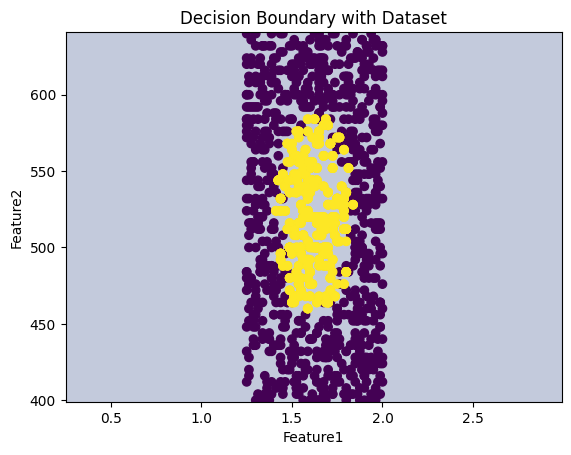

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

# Convert features to numpy arrays
X_set = X.values
y_set = y.values

# Initialize LabelEncoder
le = LabelEncoder()

# Encode y_set for scatter plot, as it's 'object' type
# Fit and transform y_set only if it contains object (string) data
if y_set.dtype == 'object':
    y_set_encoded = le.fit_transform(y_set)
else:
    y_set_encoded = y_set

# Create mesh grid
X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
    np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01)
)

# Predict for every point in grid (output will be 'Yes'/'No' strings if model was trained on strings)
Z_predictions_1d = model.predict(np.array([X1.ravel(), X2.ravel()]).T)

# Transform string predictions to numerical labels using the fitted LabelEncoder
if Z_predictions_1d.dtype == 'object':
    Z_transformed_1d = le.transform(Z_predictions_1d)
    Z = Z_transformed_1d.reshape(X1.shape).astype(float)
else:
    # If predictions are already numerical (e.g., 0s and 1s), just reshape
    Z = Z_predictions_1d.reshape(X1.shape).astype(float)

# Plot decision boundary
plt.contourf(X1, X2, Z, alpha=0.3)

# Plot original data points using encoded y_set
plt.scatter(X_set[:,0], X_set[:,1], c=y_set_encoded)

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Decision Boundary with Dataset")

plt.show()

In [54]:
plt.savefig("decision_boundary.png")

<Figure size 640x480 with 0 Axes>